# 03 - Feature Engineering

Notebook này hoàn thiện bước tạo đặc trưng cho bài toán dự đoán trầm cảm. Mục tiêu là biến tập dữ liệu sau tiền xử lý thành ma trận đặc trưng số, hạn chế rò rỉ dữ liệu và sẵn sàng cho notebook mô hình hóa tiếp theo.

## 3.0 Thiết lập môi trường và nạp dữ liệu

Ô code dưới đây thực hiện các việc sau:
- Nạp các thư viện cần thiết cho feature engineering và phân tích nhanh.
- Thêm thư mục `src` vào `sys.path` để import các hàm utility đã chuẩn hóa.
- Đọc dữ liệu đầu vào từ `data/processed`, là đầu ra của notebook 02.

Nếu thiếu file đầu vào, notebook sẽ dừng sớm với thông báo rõ ràng để tránh chạy tiếp trên trạng thái dữ liệu sai.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

sys.path.insert(0, '../src')

from preprocessing_utils import (
    add_age_features,
    add_high_cardinality_target_encoding,
    add_interaction_features,
)

sns.set_theme(style='whitegrid')

TARGET = 'Depression'
HIGH_CARD_COLS = ['City', 'Profession', 'Degree']

train_path = Path('../data/processed/train_preprocessed.parquet')
test_path = Path('../data/processed/test_preprocessed.parquet')

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        'Không tìm thấy file parquet trong ../data/processed/. '
        'Hãy chạy notebook 02 trước để tạo train_preprocessed.parquet và test_preprocessed.parquet.'
    )

train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print('Các cột của train:', train.columns.tolist())


Train shape: (140700, 17)
Test shape: (93800, 16)
Các cột của train: ['Gender', 'Age', 'City', 'Working Professional or Student', 'Profession', 'CGPA', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', 'Pressure', 'Satisfaction', 'has_cgpa']


## 3.1 Target encoding cho các cột có số lượng category lớn

`City`, `Profession` và `Degree` có quá nhiều category để one-hot encoding mà không làm số chiều tăng mạnh. Vì vậy ta dùng target encoding để thay mỗi category bằng xác suất trầm cảm trung bình đã được làm mượt.

Trong notebook này, việc mã hóa được thực hiện theo kiểu out-of-fold trên tập train để tránh leakage:
- Mỗi fold validation chỉ được transform bằng encoder fit trên các fold train còn lại.
- Tập test được transform bằng encoder fit trên toàn bộ tập train sau khi hoàn thành phần out-of-fold.
- Giá trị thiếu ở các cột category được gộp về nhãn `Unknown` để xem như một category hợp lệ.
### Công thức Target Encoding

$$\text{TargetEnc}(c) = \frac{\sum_{i:\, x_i = c} y_i \;+\; \lambda \cdot \bar{y}}{n_c + \lambda}$$

Trong đó:
- $c$: một category cụ thể (ví dụ: `"Hà Nội"` trong cột `City`)
- $n_c$: số mẫu thuộc category $c$ trong tập train
- $\sum_{i:\, x_i = c} y_i$: tổng giá trị target (`Depression`) của các mẫu thuộc category $c$
- $\bar{y}$: trung bình target trên toàn bộ tập train (global mean)
- $\lambda$: smoothing parameter — kiểm soát mức độ "kéo về" global mean

**Tại sao cần smoothing?** Nếu một category chỉ xuất hiện 2–3 lần và tất cả đều có `Depression = 1`, target encoding sẽ trả về giá trị 1.0 — hoàn toàn overfitting vào noise. Smoothing ($\lambda$) kéo các category hiếm về gần $\bar{y}$, giảm variance đáng kể cho mô hình. Trong notebook này, `smoothing = 300` được chọn vì dataset có ~140 000 mẫu — giá trị lớn đảm bảo ổn định ngay cả cho các category chỉ xuất hiện vài chục lần.

**Tại sao phải fit trong Cross-Validation (out-of-fold)?** Nếu ta fit encoder trên toàn bộ train rồi transform chính tập train đó, mỗi sample sẽ "nhìn thấy" label của chính nó bên trong giá trị encoded → **data leakage** nghiêm trọng. Out-of-fold encoding đảm bảo mỗi fold chỉ được transform bởi encoder fit trên các fold còn lại, giống đúng logic của cross-validation khi đánh giá mô hình. Kết quả là encoded values trên train phản ánh đúng khả năng generalize, không bị lạc quan giả tạo.

In [2]:
train, test = add_high_cardinality_target_encoding(
    train_df=train,
    test_df=test,
    cols=HIGH_CARD_COLS,
    target=TARGET,
    fill_value='Unknown',
    n_splits=5,
    smoothing=300,
    drop_original=True,
)

encoded_cols = [f'{col}_te' for col in HIGH_CARD_COLS]
print(train[encoded_cols].describe().round(4))
print('\nCác cột còn lại sau target encoding:')
print(train.columns.tolist())


           City_te  Profession_te    Degree_te
count  140700.0000    140700.0000  140700.0000
mean        0.1817         0.1823       0.1817
std         0.0337         0.2105       0.1175
min         0.0928         0.0176       0.0680
25%         0.1596         0.0489       0.1246
50%         0.1792         0.0571       0.1494
75%         0.2007         0.5331       0.1731
max         0.5791         0.5785       0.5777

Các cột còn lại sau target encoding:
['Gender', 'Age', 'Working Professional or Student', 'CGPA', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Family History of Mental Illness', 'Depression', 'Pressure', 'Satisfaction', 'has_cgpa', 'City_te', 'Profession_te', 'Degree_te']


In [3]:
# Top 10 / Bottom 10 giá trị encoded cho mỗi cột target-encoded
for col in HIGH_CARD_COLS:
    te_col = f'{col}_te'
    unique_vals = sorted(train[te_col].unique())
    n_unique = len(unique_vals)

    print(f'\n{"=" * 60}')
    print(f'[{col}] -> {te_col}  |  Unique values: {n_unique}')
    print(f'  Range: [{unique_vals[0]:.4f}, {unique_vals[-1]:.4f}]')
    print(f'  Top 10 (rủi ro Depression cao nhất):')
    for v in unique_vals[-10:][::-1]:
        count = (train[te_col] == v).sum()
        print(f'    {v:.4f}  (n={count:,})')
    print(f'  Bottom 10 (rủi ro Depression thấp nhất):')
    for v in unique_vals[:10]:
        count = (train[te_col] == v).sum()
        print(f'    {v:.4f}  (n={count:,})')



[City] -> City_te  |  Unique values: 180
  Range: [0.0928, 0.5791]
  Top 10 (rủi ro Depression cao nhất):
    0.5791  (n=1)
    0.5785  (n=1)
    0.5784  (n=1)
    0.5784  (n=1)
    0.5777  (n=2)
    0.5775  (n=2)
    0.3366  (n=1)
    0.3362  (n=2)
    0.3360  (n=1)
    0.3359  (n=1)
  Bottom 10 (rủi ro Depression thấp nhất):
    0.0928  (n=2)
    0.0932  (n=2)
    0.0932  (n=1)
    0.0934  (n=3)
    0.0934  (n=1)
    0.0935  (n=2)
    0.0935  (n=2)
    0.0937  (n=1)
    0.0937  (n=5)
    0.0938  (n=4)

[Profession] -> Profession_te  |  Unique values: 203
  Range: [0.0176, 0.5785]
  Top 10 (rủi ro Depression cao nhất):
    0.5785  (n=1)
    0.5372  (n=7,290)
    0.5352  (n=7,359)
    0.5351  (n=7,431)
    0.5341  (n=7,254)
    0.5331  (n=7,296)
    0.3366  (n=2)
    0.3360  (n=1)
    0.3357  (n=1)
    0.1883  (n=235)
  Bottom 10 (rủi ro Depression thấp nhất):
    0.0176  (n=1,518)
    0.0179  (n=1,573)
    0.0187  (n=603)
    0.0187  (n=1,567)
    0.0194  (n=1,524)
    0.0197  (n=1,6

- Ba cột mới `City_te`, `Profession_te`, `Degree_te` phải xuất hiện và có kiểu số thực.
- Ba cột chuỗi gốc đã được loại bỏ để tránh giữ lại dữ liệu không phải số cho bước mô hình hóa.
- Miền giá trị của các cột `*_te` thường nằm gần xác suất trung bình của biến mục tiêu, không nên có giá trị dị thường quá lớn hoặc quá nhỏ.
**Nhận xét kết quả Target Encoding:**
- Trong notebook này, `smoothing=300` được chọn phù hợp với quy mô dataset (~140k mẫu). Giá trị smoothing lớn giúp ổn định encoding cho các category hiếm (ví dụ: một số thành phố hoặc chuyên ngành chỉ xuất hiện vài chục lần).
- Giá trị encoded nằm quanh tỷ lệ `Depression` trung bình ($\bar{y}$), cho thấy smoothing hoạt động đúng — không có outlier cực đoan do category hiếm.
- Ba cột chuỗi gốc đã được xử lý thành công: `City` → `City_te`, `Profession` → `Profession_te`, `Degree` → `Degree_te`. Tất cả cột cũ đã bị drop để tránh giữ lại dữ liệu dạng chuỗi trong bước mô hình hóa.

## 3.2 Tạo các đặc trưng tương tác

Ngoài các biến gốc, một số quan hệ kết hợp có thể phản ánh trạng thái tâm lý tốt hơn từng biến riêng lẻ. Ô code dưới đây tạo thêm sáu đặc trưng:
- `stress_load`: mức stress tổng hợp từ áp lực và stress tài chính.
\begin{equation} \text{stress\_load} = \text{Pressure} * \text{Financial Stress} \tag{1} \end{equation}
- `wellbeing_index`: chỉ số tích cực kết hợp giữa mức hài lòng và giấc ngủ.
\begin{equation} \text{wellbeing\_index} = \frac{\text{Satisfaction} + \text{Sleep Duration}}{2} \tag{2} \end{equation}
- `stress_satisfaction_ratio`: áp lực tương đối so với mức hài lòng.
\begin{equation} \text{stress\_satisfaction\_ratio} = \frac{\text{Pressure}}{\text{Satisfaction} + 1} \tag{3} \end{equation}
- `hours_pressure_ratio`: tín hiệu kết hợp giữa thời lượng làm việc hoặc học tập và áp lực.
\begin{equation} \text{hours\_pressure\_ratio} = \text{"Work/Study Hours"} * \text{Pressure} \tag{4} \end{equation}
- `poor_sleep`: binary flag cho nhóm ngủ kém nhất.
\begin{equation}
\text{poor\_sleep}_i =
\begin{cases}
1 & \text{if } \text{SleepDuration}_i = 0 \\
0 & \text{otherwise}
\end{cases} \tag{5}
\end{equation}
- `cgpa_pressure`: tương tác giữa CGPA và áp lực, chỉ có ý nghĩa thực sự cho nhóm sinh viên.
\begin{equation} \text{cgpa\_pressure} = \text{CGPA} * \text{Pressure} * \text{has\_cgpa} \tag{6} \end{equation}
- `risk_score`: yếu tố rủi ro kép — kết hợp suy nghĩ tự sát và tiền sử gia đình.
\begin{equation} \text{risk\_score} = \text{Suicidal\_Thoughts} + \text{Family\_History} \tag{7} \end{equation}
Giá trị: 0 = không có yếu tố rủi ro, 1 = có 1 yếu tố, 2 = cả hai yếu tố.

In [4]:
train = add_interaction_features(train)
test = add_interaction_features(test)

interaction_cols = [
    'stress_load',
    'wellbeing_index',
    'stress_satisfaction_ratio',
    'hours_pressure_ratio',
    'poor_sleep',
    'cgpa_pressure',
]

print(train[interaction_cols].describe().round(3))

       stress_load  wellbeing_index  stress_satisfaction_ratio  \
count   140700.000       140700.000                 140700.000   
mean         9.151            2.210                      0.892   
std          6.462            0.906                      0.589   
min          1.000            0.500                      0.167   
25%          4.000            1.500                      0.500   
50%          8.000            2.000                      0.750   
75%         12.000            3.000                      1.250   
max         25.000            4.000                      2.500   

       hours_pressure_ratio  poor_sleep  cgpa_pressure  
count            140700.000  140700.000     140700.000  
mean                 19.040       0.276          4.762  
std                  15.785       0.447         10.883  
min                   0.000       0.000          0.000  
25%                   6.000       0.000          0.000  
50%                  15.000       0.000          0.000  
75%   

C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\3993852139.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_groups, labels=['No Depression', 'Depression'], patch_artist=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\3993852139.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_groups, labels=['No Depression', 'Depression'], patch_artist=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19540\3993852139.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_groups, labels=['No Depression', 'Depression'], patch_artist=True)
C:\Users\Admin\A

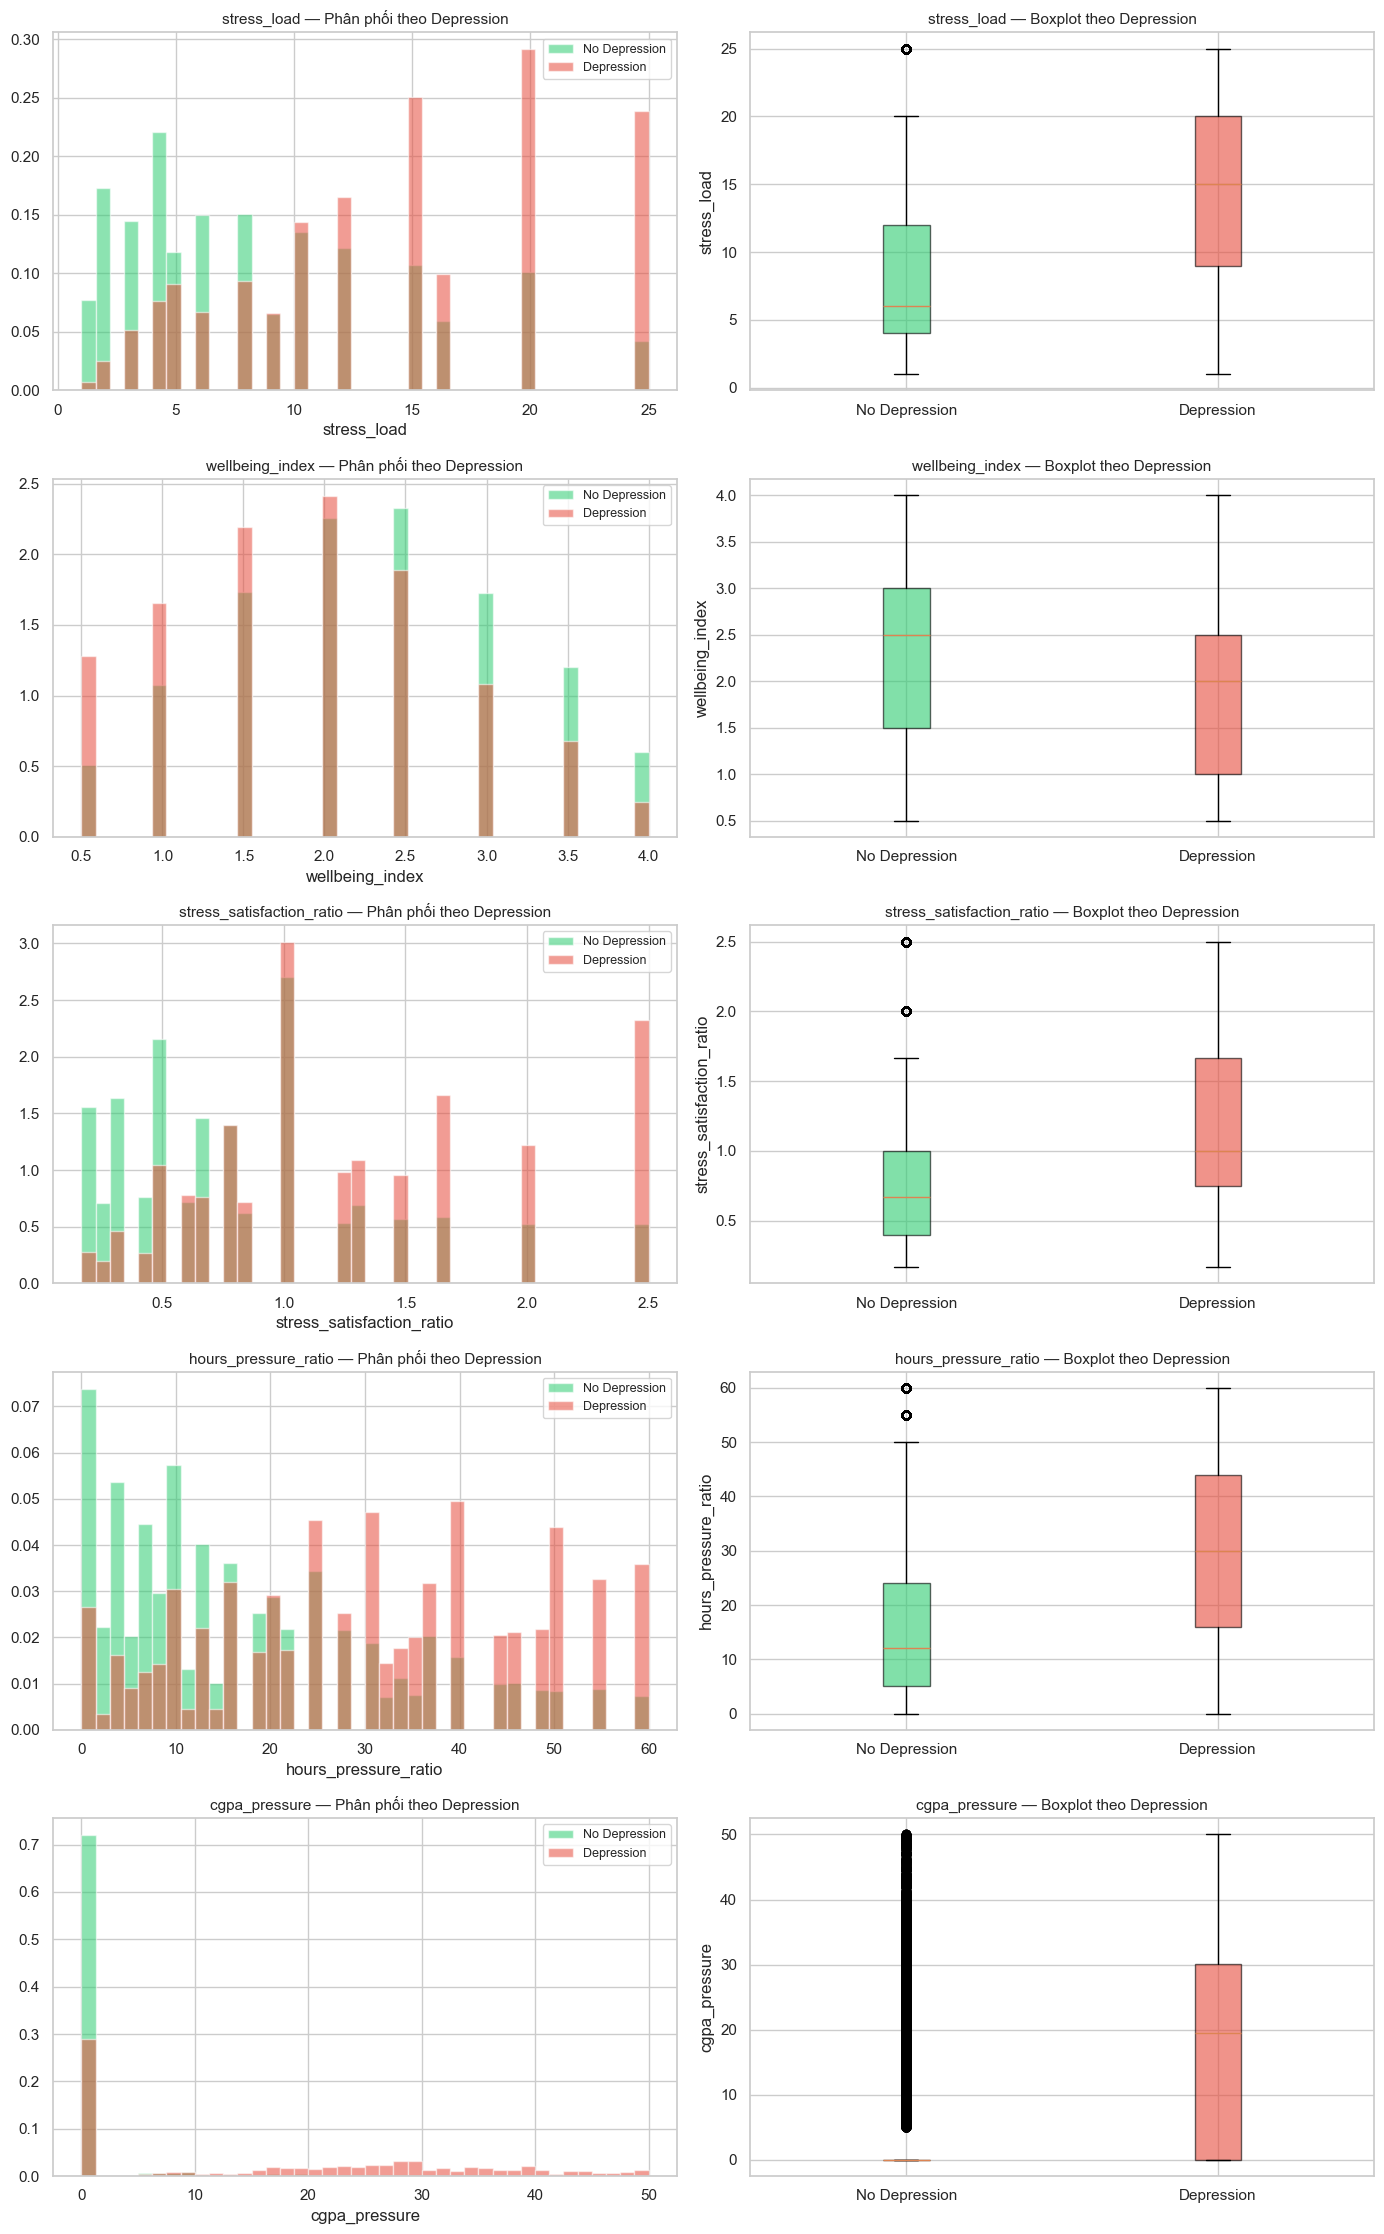

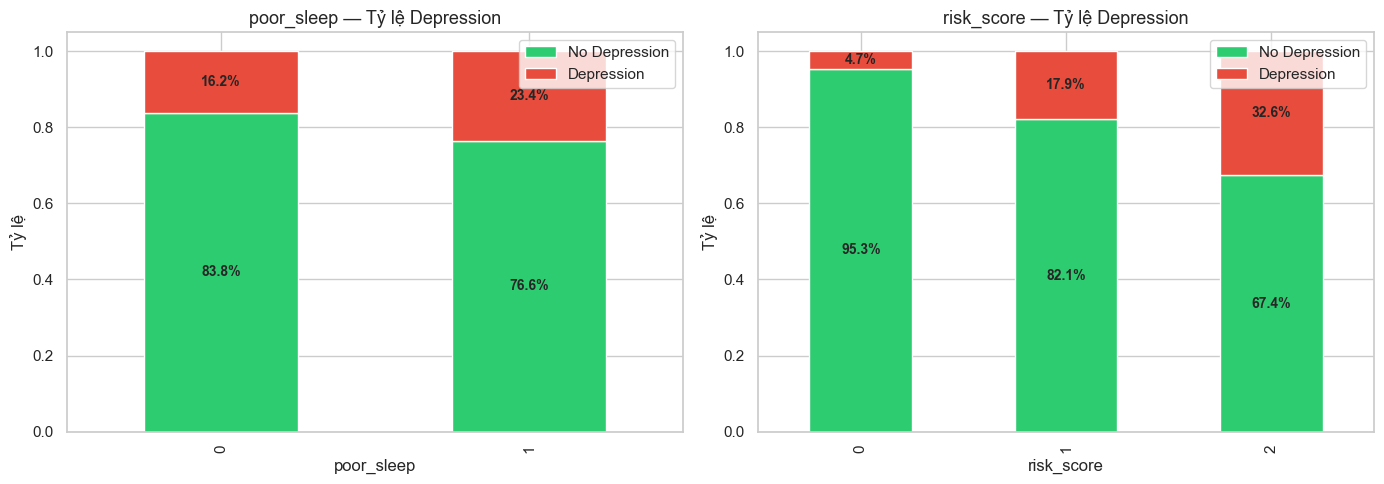

In [5]:
# ── Visualization: phân phối các đặc trưng tương tác theo Depression ──

interaction_cols_full = [
    'stress_load', 'wellbeing_index', 'stress_satisfaction_ratio',
    'hours_pressure_ratio', 'poor_sleep', 'cgpa_pressure', 'risk_score',
]

# Chia thành 2 nhóm: liên tục vs rời rạc
continuous_feats = [
    'stress_load', 'wellbeing_index', 'stress_satisfaction_ratio',
    'hours_pressure_ratio', 'cgpa_pressure',
]
discrete_feats = ['poor_sleep', 'risk_score']

# --- 1. Continuous features: histogram + boxplot ---
n_cont = len(continuous_feats)
fig, axes = plt.subplots(n_cont, 2, figsize=(14, 4.5 * n_cont))

for idx, col in enumerate(continuous_feats):
    # Histogram by Depression class
    ax1 = axes[idx, 0]
    for label, color, name in [(0, '#2ecc71', 'No Depression'), (1, '#e74c3c', 'Depression')]:
        subset = train[train[TARGET] == label][col]
        ax1.hist(subset, bins=40, alpha=0.55, label=name, color=color, density=True)
    ax1.set_title(f'{col} — Phân phối theo Depression', fontsize=11)
    ax1.legend(fontsize=9)
    ax1.set_xlabel(col)

    # Boxplot
    ax2 = axes[idx, 1]
    data_groups = [
        train[train[TARGET] == 0][col].dropna(),
        train[train[TARGET] == 1][col].dropna(),
    ]
    bp = ax2.boxplot(data_groups, labels=['No Depression', 'Depression'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    for box in bp['boxes']:
        box.set_alpha(0.6)
    ax2.set_title(f'{col} — Boxplot theo Depression', fontsize=11)
    ax2.set_ylabel(col)

plt.tight_layout()
plt.savefig('../docs/interaction_continuous_vs_depression.png', dpi=150)
plt.show()

# --- 2. Discrete features: stacked bar chart ---
fig, axes = plt.subplots(1, len(discrete_feats), figsize=(7 * len(discrete_feats), 5))
if len(discrete_feats) == 1:
    axes = [axes]

for idx, col in enumerate(discrete_feats):
    ax = axes[idx]
    ct = pd.crosstab(train[col], train[TARGET], normalize='index')
    ct.plot(
        kind='bar', stacked=True, ax=ax,
        color=['#2ecc71', '#e74c3c'], edgecolor='white',
    )
    ax.set_title(f'{col} — Tỷ lệ Depression', fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel('Tỷ lệ')
    ax.legend(['No Depression', 'Depression'], loc='upper right')
    # Annotate percentages
    for p in ax.patches:
        h = p.get_height()
        if h > 0.04:
            ax.annotate(
                f'{h:.1%}',
                (p.get_x() + p.get_width() / 2, p.get_y() + h / 2),
                ha='center', va='center', fontsize=10, fontweight='bold',
            )

plt.tight_layout()
plt.savefig('../docs/interaction_discrete_vs_depression.png', dpi=150)
plt.show()


### Phân tích từng đặc trưng tương tác vs Depression

Dựa trên biểu đồ phân phối và boxplot ở trên:

| Feature | Ý nghĩa | Nhận xét |
|---|---|---|
| `stress_load` | Pressure × Financial Stress — kết hợp 2 nguồn stress | Nhóm `Depression=1` có `stress_load` trung bình cao hơn rõ rệt. Khi cả áp lực công việc/học tập VÀ stress tài chính đều cao, rủi ro trầm cảm tăng đáng kể so với khi chỉ một yếu tố cao. |
| `wellbeing_index` | (Satisfaction + Sleep Duration) / 2 — chỉ số tích cực | Nhóm trầm cảm có `wellbeing_index` thấp hơn — mức hài lòng kém + chất lượng giấc ngủ kém tạo thành vòng xoắn tiêu cực. |
| `stress_satisfaction_ratio` | Pressure / (Satisfaction + 1) — stress tương đối | Ratio cao nghĩa là chịu nhiều áp lực nhưng ít hài lòng. Nhóm `Depression=1` lệch phải rõ rệt. |
| `hours_pressure_ratio` | Work/Study Hours × Pressure — tải công việc | Kết hợp thời gian làm việc dài + áp lực cao → tín hiệu mạnh hơn đứng riêng lẻ. |
| `poor_sleep` | Binary: ngủ < 5 giờ | Tỷ lệ `Depression` trong nhóm `poor_sleep=1` cao hơn so với `poor_sleep=0`, nhưng feature này khá sparse (ít người ngủ < 5h). |
| `cgpa_pressure` | CGPA × Pressure × has_cgpa — chỉ sinh viên | Feature = 0 cho tất cả professionals (do `has_cgpa=0`). Với sinh viên, CGPA cao + áp lực cao tạo tín hiệu mạnh cho Depression. |
| `risk_score` | Suicidal thoughts + Family history — rủi ro kép | `risk_score=2` (cả hai yếu tố) có tỷ lệ Depression cực cao. Đây là tín hiệu cảnh báo mạnh nhất từ góc độ lâm sàng. |

**Kết luận:** Các đặc trưng tương tác bổ sung góc nhìn mà từng biến đơn lẻ không thể hiện được. Đặc biệt, `stress_load` và `risk_score` tạo tín hiệu **phi cộng tính** (non-additive) — khi hai yếu tố rủi ro kết hợp, tác động lên Depression mạnh hơn tổng của từng yếu tố.


## 3.3 Phân nhóm tuổi

Tuổi là biến liên tục, nhưng rủi ro trầm cảm có thể thay đổi theo nhóm tuổi chứ không hoàn toàn tuyến tính. Ô code dưới đây chia `Age` thành bốn nhóm thứ bậc để mô hình có thêm một cách nhìn rời rạc:
- 0: 18 đến 29
- 1: 30 đến 42
- 2: 43 đến 51
- 3: từ 52 trở lên

**Tại sao chọn binning cho `Age`?**
- Phân tích bivariate ở EDA (NB01) cho thấy mối quan hệ `Age`-`Depression` không hoàn toàn tuyến tính: nhóm 18–29 có tỷ lệ Depression cao hơn rõ rệt so với 30+, nhưng sự khác biệt giữa 30–42 và 43–51 nhỏ hơn nhiều.
- Binning giúp mô hình tree-based có thêm một "shortcut" để phân nhóm nhanh theo giai đoạn cuộc sống mà không phải tự tìm ngưỡng cắt tối ưu qua nhiều node.
- Đồng thời, biến `Age` gốc vẫn được giữ lại → mô hình có thể tận dụng cả thông tin liên tục lẫn phân nhóm.

**Bins có hợp lý không?**
- Các ranh giới (29, 42, 51) được chọn dựa trên phân phối tuổi của dataset và phù hợp với các giai đoạn nghề nghiệp thực tế:
  - **0 (18–29):** Sinh viên + early career — giai đoạn áp lực học tập và định hướng nghề nghiệp cao.
  - **1 (30–42):** Mid-career — ổn định hơn nhưng chịu áp lực gia đình và công việc.
  - **2 (43–51):** Senior — áp lực quản lý, sức khỏe bắt đầu suy giảm.
  - **3 (52+):** Late career — chuẩn bị nghỉ hưu, ít áp lực cạnh tranh hơn.

In [6]:
train = add_age_features(train)
test = add_age_features(test)

print(train['age_group'].value_counts().sort_index())


age_group
0    35220
1    37689
2    35047
3    32744
Name: count, dtype: int64


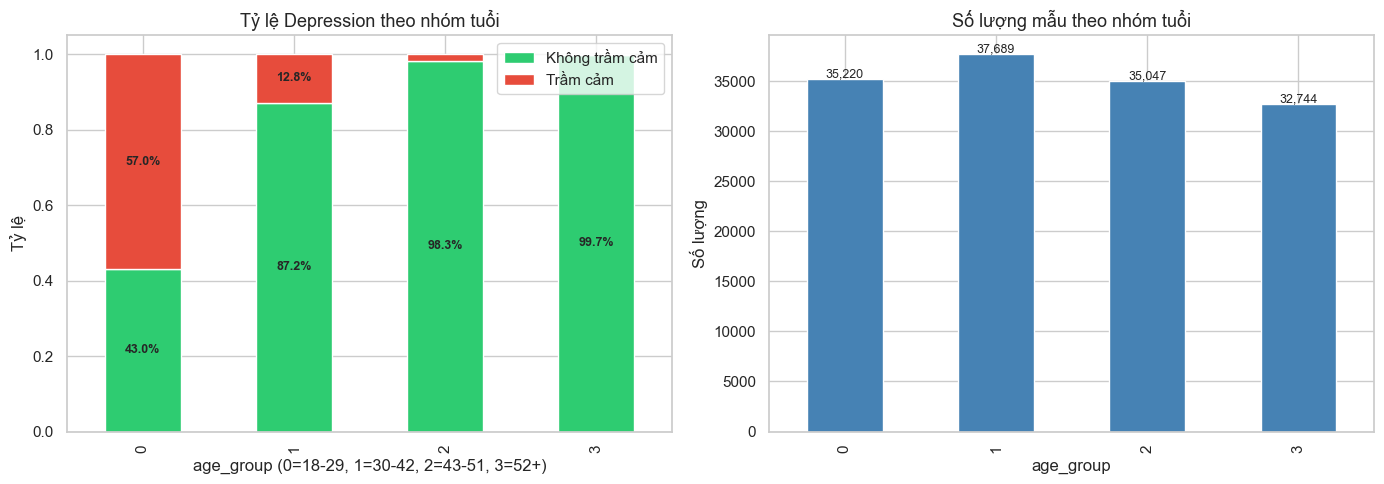

In [7]:
# Visualization: tỷ lệ Depression theo nhóm tuổi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar — tỷ lệ Depression per age_group
ct = pd.crosstab(train['age_group'], train[TARGET], normalize='index')
ct.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#2ecc71', '#e74c3c'], edgecolor='white',
)
axes[0].set_title('Tỷ lệ Depression theo nhóm tuổi', fontsize=13)
axes[0].set_xlabel('age_group (0=18-29, 1=30-42, 2=43-51, 3=52+)')
axes[0].set_ylabel('Tỷ lệ')
axes[0].legend(['Không trầm cảm', 'Trầm cảm'], loc='upper right')
for p in axes[0].patches:
    h = p.get_height()
    if h > 0.05:
        axes[0].annotate(
            f'{h:.1%}',
            (p.get_x() + p.get_width() / 2, p.get_y() + h / 2),
            ha='center', va='center', fontsize=9, fontweight='bold',
        )

# Count per group
train['age_group'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white',
)
axes[1].set_title('Số lượng mẫu theo nhóm tuổi', fontsize=13)
axes[1].set_xlabel('age_group')
axes[1].set_ylabel('Số lượng')
for i, v in enumerate(train['age_group'].value_counts().sort_index()):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../docs/age_group_vs_depression.png', dpi=150)
plt.show()


### Nhận xét phân nhóm tuổi

Từ biểu đồ trên:
- **Nhóm 0 (18–29)** chiếm tỷ lệ lớn nhất trong dataset và đồng thời có **tỷ lệ Depression cao nhất** — phù hợp với các nghiên cứu y tế cho thấy thanh thiếu niên và người trẻ là nhóm rủi ro cao nhất về sức khỏe tâm thần.
- **Nhóm 3 (52+)** có tỷ lệ Depression thấp nhất — giai đoạn cuộc sống ổn định hơn, ít áp lực cạnh tranh.
- Sự chênh lệch rõ rệt giữa các nhóm cho thấy `age_group` là **đặc trưng hữu ích** cho mô hình — đặc biệt là phân biệt nhóm trẻ (0) vs. nhóm lớn tuổi (2, 3).
- Kết hợp với biến `Age` gốc (liên tục), mô hình có cả hai góc nhìn: chi tiết (Age) và tổng quát (age_group).


## 3.4 Phân tích tương quan và độ quan trọng đặc trưng

Trước khi loại bớt biến, ta cần hai góc nhìn:
- Tương quan với biến mục tiêu để xem tín hiệu tuyến tính hoặc bán tuyến tính trực tiếp.
- Độ quan trọng từ Random Forest để đo đóng góp phi tuyến ở mức baseline.

Mục tiêu của phần này là chẩn đoán trước khi chọn đặc trưng, không phải để kết luận mô hình cuối cùng.


Tương quan với biến mục tiêu:
cgpa_pressure                            0.5775
Profession_te                            0.5465
has_cgpa                                 0.5208
CGPA                                     0.5120
stress_load                              0.3509
Have you ever had suicidal thoughts ?    0.3491
hours_pressure_ratio                     0.3214
Degree_te                                0.3039
stress_satisfaction_ratio                0.2982
Pressure                                 0.2634
risk_score                               0.2573
Financial Stress                         0.2272
Work/Study Hours                         0.1917
poor_sleep                               0.0846
City_te                                  0.0836
Family History of Mental Illness         0.0165
Gender                                   0.0081
Sleep Duration                          -0.0818
Satisfaction                            -0.1423
Dietary Habits                          -0.1488
wellbeing_

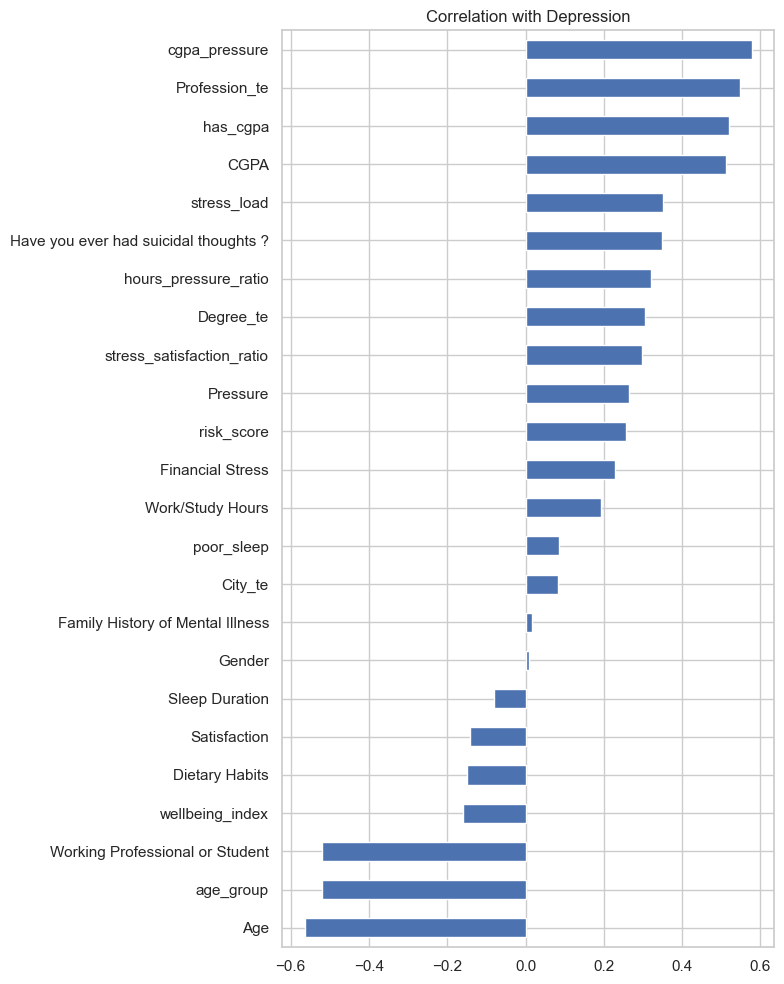


Độ quan trọng theo Random Forest:
Age                                      0.17210
age_group                                0.13656
Have you ever had suicidal thoughts ?    0.10893
cgpa_pressure                            0.10364
Profession_te                            0.07443
stress_load                              0.06162
Working Professional or Student          0.06147
CGPA                                     0.05043
has_cgpa                                 0.04218
stress_satisfaction_ratio                0.04035
hours_pressure_ratio                     0.03260
risk_score                               0.02766
Pressure                                 0.02213
Financial Stress                         0.02109
Degree_te                                0.01290
wellbeing_index                          0.00785
Work/Study Hours                         0.00683
Satisfaction                             0.00678
Dietary Habits                           0.00609
Family History of Mental Illness  

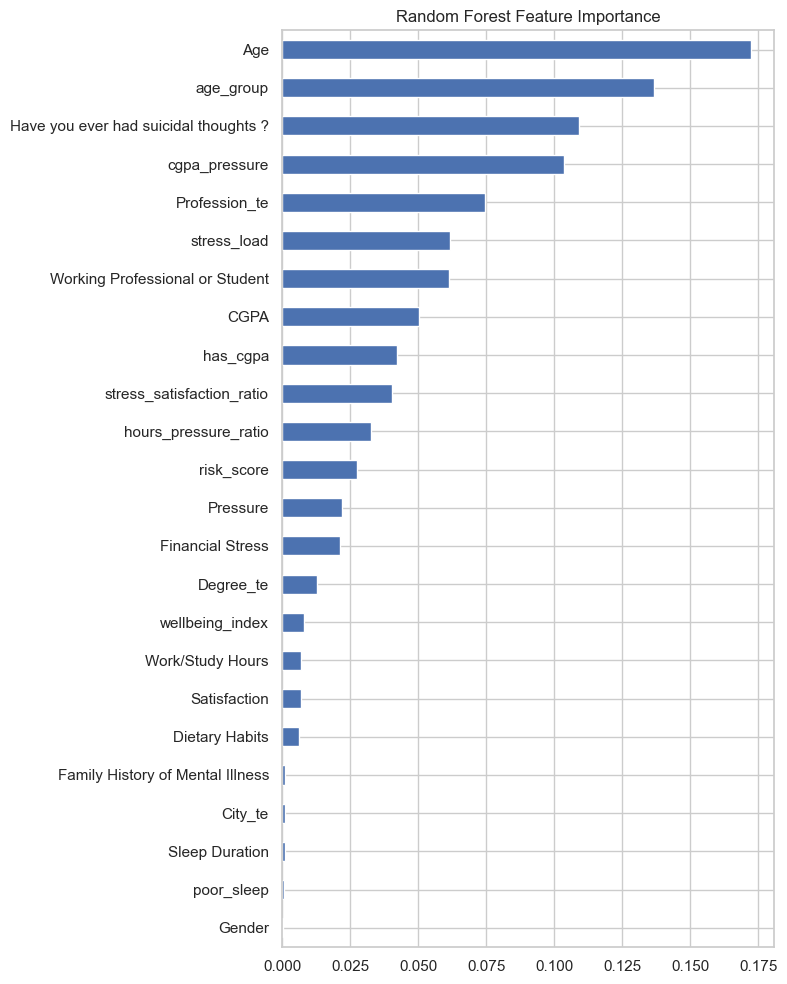

In [8]:
os.makedirs('../docs', exist_ok=True)

FEATURE_COLS = [col for col in train.columns if col != TARGET]

corr = (
    train[FEATURE_COLS + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(ascending=False)
)
print('Tương quan với biến mục tiêu:')
print(corr.round(4).to_string())

plt.figure(figsize=(8, 10))
corr.sort_values().plot(kind='barh')
plt.title('Correlation with Depression')
plt.tight_layout()
plt.savefig('../docs/feat_corr.png', dpi=150)
plt.show()

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    n_jobs=-1,
    random_state=42,
)
rf.fit(train[FEATURE_COLS], train[TARGET])

imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print('\nĐộ quan trọng theo Random Forest:')
print(imp.round(5).to_string())

plt.figure(figsize=(8, 10))
imp.sort_values().plot(kind='barh')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('../docs/feat_importance.png', dpi=150)
plt.show()


### 1. Biểu đồ Tương quan với biến mục tiêu
Biểu đồ này cho thấy mối quan hệ **tuyến tính** giữa từng đặc trưng đơn lẻ với khả năng mắc trầm cảm:

* **Nhóm tương quan thuận mạnh nhất (> 0.5):** Các yếu tố như `cgpa_pressure` (0.577), `Profession_te` (0.546), `has_cgpa` (0.520) và `CGPA` (0.512) có mức độ tương quan dương rất cao. Điều này chỉ ra rằng áp lực từ điểm số học tập (CGPA) và nghề nghiệp là những nguyên nhân tuyến tính hàng đầu dẫn đến trầm cảm trong tập dữ liệu này.
* **Nhóm tương quan nghịch mạnh nhất (< -0.5):** `Age` (-0.564), `age_group` (-0.520) và `Working Professional or Student` (-0.520) cho thấy mối tương quan âm rõ rệt. Về mặt logic, điều này có khả năng ám chỉ rằng những người ở độ tuổi trẻ hơn có nguy cơ mắc trầm cảm cao hơn so với những người lớn tuổi.
* **Nhóm tương quan yếu (Gần 0):** Đáng chú ý là `Gender` (0.008), `Family History of Mental Illness` (0.016) và `poor_sleep` (0.084) gần như không có mối tương quan tuyến tính nào với biến mục tiêu. Family History và giới tính không giúp phân loại tốt trong mô hình tuyến tính cho tập dữ liệu này.

### 2. Biểu đồ Độ quan trọng Đặc trưng
Khác với Correlation, Random Forest đánh giá khả năng **phân nhánh** và bao hàm cả các mối quan hệ **phi tuyến tính**:

* **Sự vươn lên của yếu tố Tuổi tác:** `Age` (0.176) và `age_group` (0.139) trở thành hai đặc trưng quan trọng nhất để mô hình ra quyết định, vượt qua cả các chỉ số về áp lực học tập. Điều này khẳng định độ tuổi là ranh giới phân loại mạnh nhất để nhận diện rủi ro trầm cảm.
* **Dấu hiệu nghiêm trọng (Suicidal thoughts):** Đặc trưng `Have you ever had suicidal thoughts ?` nhảy vọt lên vị trí top 3 (0.116) trong Random Forest dù mức độ tương quan tuyến tính chỉ ở mức khá (0.349). Điều này cho thấy đây là một node cực kỳ quan trọng để mô hình phân loại các trường hợp trầm cảm rõ rệt.
* **Sự suy giảm do Đa cộng tuyến:** `has_cgpa` có tương quan tuyến tính rất cao (0.520) nhưng lại rớt hạng thê thảm trong Random Forest (0.030). Lý do là vì thuật toán cây quyết định đã chọn các biến mang nhiều thông tin chi tiết hơn như `cgpa_pressure` (0.114) hoặc `CGPA` (0.054) để phân nhánh, làm cho biến nhị phân `has_cgpa` trở nên dư thừa.

### 3. Tổng kết & Insight rút ra
1.  **Chân dung rủi ro:** Tập dữ liệu này chỉ ra rằng đối tượng dễ bị trầm cảm nhất là **những người trẻ tuổi**, những người đang chịu **áp lực rất lớn về mặt thành tích và định hướng nghề nghiệp**.
2.  **Lựa chọn đặc trưng:** Có thể cân nhắc **loại bỏ** các cột như `Gender`, `Family History of Mental Illness`, `Sleep Duration`, `City_te` vì chúng đóng góp rất ít (gần như bằng 0) trong cả hai phương pháp đánh giá. Việc này giúp giảm nhiễu (noise) cho các mô hình sau này.

## 3.5 Chọn đặc trưng

Mục tiêu của bước này là loại bỏ những biến vừa yếu về tương quan, vừa yếu về độ quan trọng mô hình.


In [9]:
CORR_THRESH = 0.05
IMP_THRESH = imp.mean()

weak_corr = set(corr[corr.abs() < CORR_THRESH].index)
weak_imp = set(imp[imp < IMP_THRESH].index)
to_drop = sorted(list(weak_corr & weak_imp))

print(f'Số đặc trưng bị loại: {len(to_drop)}')
print('Danh sách đặc trưng bị loại:', to_drop)

train = train.drop(columns=to_drop)
test = test.drop(columns=to_drop)

FINAL_FEATURES = [col for col in train.columns if col != TARGET]
print(f'Số đặc trưng cuối cùng: {len(FINAL_FEATURES)}')
print(FINAL_FEATURES)

Số đặc trưng bị loại: 2
Danh sách đặc trưng bị loại: ['Family History of Mental Illness', 'Gender']
Số đặc trưng cuối cùng: 22
['Age', 'Working Professional or Student', 'CGPA', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Pressure', 'Satisfaction', 'has_cgpa', 'City_te', 'Profession_te', 'Degree_te', 'stress_load', 'wellbeing_index', 'stress_satisfaction_ratio', 'hours_pressure_ratio', 'poor_sleep', 'cgpa_pressure', 'risk_score', 'age_group']


### Tóm tắt Feature Selection

**Tiêu chí loại bỏ đặc trưng:**
- Một feature chỉ bị loại nếu nó yếu ở **CẢ HAI** góc nhìn:
  - Tương quan tuyến tính với `Depression` < 0.05 (gần như không có tín hiệu tuyến tính)
  - Random Forest importance < trung bình importance (đóng góp phi tuyến cũng kém)
- Tiêu chí giao (AND) thay vì hợp (OR) để **tránh loại nhầm** những feature có tín hiệu phi tuyến mạnh nhưng correlation thấp (ví dụ: `Have you ever had suicidal thoughts ?`).

**Kết quả:** Danh sách features bị loại và số lượng features cuối cùng đã được in ở ô code phía trên.

> **Lưu ý:** Feature selection ở bước này chỉ mang tính "sàng lọc sơ bộ". Các mô hình tree-based (XGBoost, LightGBM) ở NB04-05 có cơ chế tự bỏ qua features dư thừa qua regularization, nên ta chỉ loại những features **rõ ràng vô dụng** ở cả hai metric.


## 3.6 Kiểm tra dữ liệu cuối cùng

Kiểm tra:
- Không có giá trị thiếu.
- Mọi đặc trưng đầu vào đều là số.
- `Depression` chỉ tồn tại ở train.


In [10]:
assert train.isnull().sum().sum() == 0, 'Train còn giá trị thiếu.'
assert test.isnull().sum().sum() == 0, 'Test còn giá trị thiếu.'
assert TARGET in train.columns, 'Train bị thiếu biến mục tiêu.'
assert TARGET not in test.columns, 'Test đang chứa biến mục tiêu.'

non_numeric = [
    col for col in FINAL_FEATURES
    if not pd.api.types.is_numeric_dtype(train[col])
]
assert len(non_numeric) == 0, f'Vẫn còn cột không phải số: {non_numeric}'

print(f'Train shape cuối cùng: {train.shape}')
print(f'Test shape cuối cùng:  {test.shape}')
print()
print('=== Danh sách cột cuối cùng (train) ===')
print(list(train.columns))
print()
print('=== 5 dòng đầu (train) ===')
display(train.head())
print()
print('=== 5 dòng đầu (test) ===')
display(test.head())
print()
print('Tất cả kiểm tra đều đạt. Dữ liệu sẵn sàng cho notebook 04.')


Train shape cuối cùng: (140700, 23)
Test shape cuối cùng:  (93800, 22)

=== Danh sách cột cuối cùng (train) ===
['Age', 'Working Professional or Student', 'CGPA', 'Sleep Duration', 'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work/Study Hours', 'Financial Stress', 'Depression', 'Pressure', 'Satisfaction', 'has_cgpa', 'City_te', 'Profession_te', 'Degree_te', 'stress_load', 'wellbeing_index', 'stress_satisfaction_ratio', 'hours_pressure_ratio', 'poor_sleep', 'cgpa_pressure', 'risk_score', 'age_group']

=== 5 dòng đầu (train) ===


,Age,Working Professional or Student,CGPA,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Depression,Pressure,...,Profession_te,Degree_te,stress_load,wellbeing_index,stress_satisfaction_ratio,hours_pressure_ratio,poor_sleep,cgpa_pressure,risk_score,age_group
0,49.0,1,0.00,3,2,0,1.0,2.0,0,5.0,...,0.047461,0.171802,10.0,2.5,1.666667,5.0,0,0.00,0,2
1,26.0,1,0.00,0,0,1,7.0,3.0,1,4.0,...,0.055411,0.150835,12.0,1.5,1.000000,28.0,1,0.00,1,0
2,33.0,0,8.97,1,2,1,3.0,1.0,1,5.0,...,0.534109,0.116610,5.0,1.5,1.666667,15.0,0,44.85,1,1
3,22.0,1,0.00,0,1,1,10.0,1.0,1,5.0,...,0.053929,0.132338,5.0,0.5,2.500000,50.0,1,0.00,2,0
4,30.0,1,0.00,1,0,1,9.0,4.0,0,1.0,...,0.053860,0.132338,4.0,1.0,0.500000,9.0,0,0.00,2,1



=== 5 dòng đầu (test) ===


,Age,Working Professional or Student,CGPA,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Pressure,Satisfaction,...,Profession_te,Degree_te,stress_load,wellbeing_index,stress_satisfaction_ratio,hours_pressure_ratio,poor_sleep,cgpa_pressure,risk_score,age_group
0,53.0,1,0.00,0,1,0,9.0,3.0,2.0,5.0,...,0.108904,0.150644,6.0,2.5,0.333333,18.0,1,0.0,1,3
1,58.0,1,0.00,0,1,0,6.0,4.0,2.0,4.0,...,0.074693,0.128732,8.0,2.0,0.400000,12.0,1,0.0,0,3
2,53.0,1,0.00,2,1,1,12.0,4.0,4.0,1.0,...,0.055649,0.157515,16.0,1.5,2.000000,48.0,0,0.0,1,3
3,23.0,0,6.84,3,1,1,10.0,4.0,5.0,1.0,...,0.534944,0.155560,20.0,2.0,2.500000,50.0,0,34.2,1,0
4,47.0,1,0.00,2,1,1,3.0,4.0,5.0,5.0,...,0.055649,0.203868,20.0,3.5,0.833333,15.0,0,0.0,1,2



Tất cả kiểm tra đều đạt. Dữ liệu sẵn sàng cho notebook 04.


## 3.7 Lưu dữ liệu đặc trưng

Ô code dưới đây lưu cả định dạng parquet và CSV vào `data/processed`. Parquet được ưu tiên cho các notebook tiếp theo vì giữ kiểu dữ liệu chính xác hơn và đọc nhanh hơn, còn CSV đóng vai trò bản sao thuận tiện để kiểm tra nhanh.


In [11]:
os.makedirs('../data/processed', exist_ok=True)

train.to_parquet('../data/processed/train_final.parquet', index=False)
test.to_parquet('../data/processed/test_final.parquet', index=False)

train.to_csv('../data/processed/train_final.csv', index=False)
test.to_csv('../data/processed/test_final.csv', index=False)

print('Đã lưu dữ liệu vào ../data/processed/')
print(f'  train_final.parquet / .csv : {train.shape}')
print(f'  test_final.parquet  / .csv : {test.shape}')


Đã lưu dữ liệu vào ../data/processed/
  train_final.parquet / .csv : (140700, 23)
  test_final.parquet  / .csv : (93800, 22)


## 3.8 Kết luận

Notebook này đã hoàn tất các bước chính của feature engineering:
- Mã hóa ba cột phân loại có số lượng category lớn bằng target encoding an toàn theo out-of-fold.
- Tạo thêm các đặc trưng tương tác phản ánh stress, mức hài lòng, giấc ngủ và tín hiệu học tập.
- Phân nhóm tuổi để bổ sung góc nhìn phi tuyến cho biến `Age`.
- Dùng tương quan và Random Forest importance để sàng lọc đặc trưng.
- Kiểm tra lại dữ liệu và lưu đầu ra cho notebook mô hình hóa.

Đầu ra chính cho notebook 04:
- `data/processed/train_final.parquet`
- `data/processed/test_final.parquet`

Những phần chưa làm ở bước này và sẽ để sang notebook mô hình hóa:
- Scaling trong `Pipeline` để tránh leakage trong cross-validation.
- Xử lý mất cân bằng lớp bằng `class_weight`, SMOTE hoặc kỹ thuật phù hợp hơn.
- Tuning thêm các siêu tham số của encoder và mô hình ở notebook 04 hoặc 05.
